# **Case Study 2: Credit Card Fraud Detection using XGBoost & SMOTE**
This notebook demonstrates a complete workflow to handle heavily imbalanced credit card transactions, apply SMOTE (Synthetic Minority Over-sampling Technique), train an XGBoost model, optimize the decision threshold, and interpret the feature importances.

In [19]:
# Install necessary librariesa
!pip install -q imbalanced-learn xgboost

### **Downloading And Loading Dataset**
1. Download and Load Dataset
We will use the standard Kaggle Credit Card Fraud Detection dataset. Since accessing the Kaggle API directly requires credentials, we will provide a helper script to automatically download the dataset from a public mirror if it is not already present locally.

In [20]:
import pandas as pd
import numpy as np
import os
import urllib.request


url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
csv_path = "creditcard.csv"

if not os.path.exists(csv_path):
    print("Downloading creditcard.csv...")
    urllib.request.urlretrieve(url, csv_path)
    print("Download complete.")
else:
    print("Dataset already exists locally.")

df = pd.read_csv(csv_path)
display(df.head())


print("\nClass Distribution:")
print(df['Class'].value_counts())
print(f"Percentage of fraudulent transactions: {df['Class'].mean() * 100:.4f}%")

Dataset already exists locally.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Percentage of fraudulent transactions: 0.1727%


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [22]:
df.isnull().sum().sum()

np.int64(0)

In [23]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [24]:
df.duplicated().sum()

np.int64(1081)

In [25]:
df.drop_duplicates(inplace=True)

### 2. Train-Test Split & SMOTE (Oversampling)
To avoid data leakage, we first split our dataset into training and testing sets, then apply SMOTE **only** to our training set.

In [26]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler


X = df.drop(columns=['Class'])
y = df['Class']


scaler = StandardScaler()
X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original training shape: {X_train.shape} with {y_train.sum()} frauds")
print(f"Resampled training shape: {X_train_res.shape} with {y_train_res.sum()} frauds")

Original training shape: (226980, 30) with 378 frauds
Resampled training shape: (453204, 30) with 226602 frauds


### 3. Model Training (XGBoost)
We train an XGBoost classifier on the SMOTE-balanced training dataset.

In [27]:
import xgboost as xgb


xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf.fit(X_train_res, y_train_res)

print("XGBoost model training completed.")

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [18:53:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model training completed.


### 4. Evaluate Threshold Tuning
By default, classifiers predict positive instances at a threshold of 0.5. For fraud detection, we often want a lower threshold to catch more fraudulent cases (higher recall), even if it yields some false alarms (lower precision).

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve,recall_score,precision_score,accuracy_score,f1_score

y_pred = xgb_clf.predict(X_test)
import matplotlib.pyplot as plt

y_probs = xgb_clf.predict_proba(X_test)[:, 1]

thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]

for th in thresholds:
    y_pred_th = (y_probs >= th).astype(int)
    print(f"\n--- Classification Report at Threshold: {th} ---")
    print(classification_report(y_test, y_pred_th))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_th))


--- Classification Report at Threshold: 0.1 ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.45      0.82      0.58        95

    accuracy                           1.00     56746
   macro avg       0.72      0.91      0.79     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix:
[[56555    96]
 [   17    78]]

--- Classification Report at Threshold: 0.3 ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.60      0.81      0.69        95

    accuracy                           1.00     56746
   macro avg       0.80      0.90      0.84     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix:
[[56600    51]
 [   18    77]]

--- Classification Report at Threshold: 0.5 ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   

In [31]:
precision_score(y_test, y_pred)

0.7115384615384616

In [32]:
recall_score(y_test, y_pred)

0.7789473684210526

In [34]:
f1_score(y_test, y_pred)

0.7437185929648241

/tmp/ipykernel_1356/42622104.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='coolwarm')


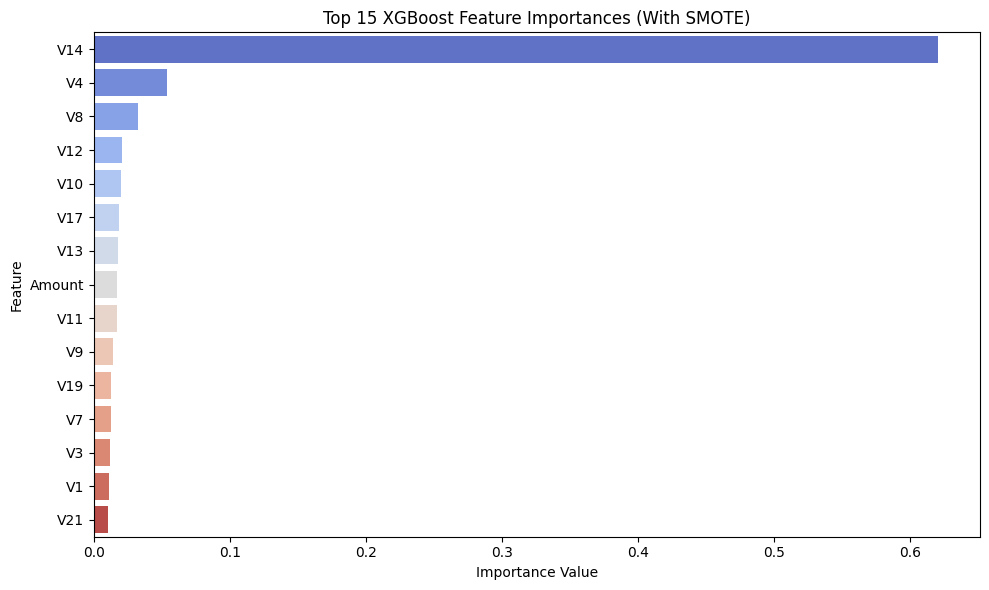

In [35]:
import seaborn as sns


importances = xgb_clf.feature_importances_
feature_names = X.columns


importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(15)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='coolwarm')
plt.title('Top 15 XGBoost Feature Importances (With SMOTE)')
plt.xlabel('Importance Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()